In [1]:
list.of.packages <- c("tidyverse","sf","stargazer")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.10.2, GDAL 3.4.1, PROJ 8.2.1; sf_use_s2() is TRUE


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 




# DHS clusters

In [2]:
path_geo_15 <- "/input/IA_2015-16_DHS/IAGE71FL_GeoData_shp/IAGE71FL.shp"
sf_DHS_15 <- st_read(path_geo_15)

Reading layer `IAGE71FL' from data source 
  `/home/claire/Dropbox/PSE_doctorant/Data/DHS/input/IA_2015-16_DHS/IAGE71FL_GeoData_shp/IAGE71FL.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 28526 features and 20 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 0 ymin: 0 xmax: 97.05009 ymax: 34.84734
Geodetic CRS:  WGS 84


In [3]:
path_geo_19 <- "/input/IA_2019-21_DHS/IAGE7AFL_GeoData_shp/IAGE7AFL.shp"
sf_DHS_19 <- st_read(path_geo_19)

Reading layer `IAGE7AFL' from data source 
  `/home/claire/Dropbox/PSE_doctorant/Data/DHS/input/IA_2019-21_DHS/IAGE7AFL_GeoData_shp/IAGE7AFL.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 30197 features and 20 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 0 ymin: 0 xmax: 97.09112 ymax: 34.78092
Geodetic CRS:  WGS 84


# 2011 district shapefile

In [4]:
path_districts <- "../district_borders/Census_2011/2011_Dist.shp"
districts <- st_read(path_districts)

Reading layer `2011_Dist' from data source 
  `/home/claire/Dropbox/PSE_doctorant/Data/district_borders/Census_2011/2011_Dist.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 641 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 68.18625 ymin: 6.755953 xmax: 97.41529 ymax: 37.07827
Geodetic CRS:  WGS 84


In [5]:
theme_map <- function(...) {
  # On part du theme minimal, qui existe déjà
  # on retire juste les axes
  theme(
    title = element_text(size = 24),
    axis.line = element_blank(),
    axis.ticks = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 16),
    legend.key.size = unit(1, "cm"),
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    panel.background = element_rect(fill = "aliceblue"),
  )
}

In [6]:
districts%>%mutate(issue=ifelse(toupper(DISTRICT)=="DATA NOT AVAILABLE",1,0))%>%filter(issue==1)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,geometry,issue
,<chr>,<chr>,<int>,<int>,<dbl>,<MULTIPOLYGON [°]>,<dbl>
1,Data Not Available,Jammu & Kashmir,99,99,0,MULTIPOLYGON (((74.7146 37....,1


In [7]:
districts_km2 <- districts %>%
                    filter(DISTRICT != "Data Not Available")%>%
                    st_make_valid()%>%
                    mutate(area_km2 = as.numeric(st_area(.) / units::as_units("km^2")))%>%
                    st_drop_geometry()

In [8]:
districts_km2 %>%
        stargazer(nobs=TRUE, digits = 2,
        summary.stat = c("n","mean", "sd","min","p25","median","p75","max"),
        title = c("Summary statistics"),
        type="text")


Summary statistics
Statistic   N    Mean   St. Dev. Min  Pctl(25)  Median  Pctl(75)    Max   
--------------------------------------------------------------------------
ST_CEN_CD  640  17.11     9.43    1      9        18       24       35    
DT_CEN_CD  640  16.02    13.68    1      6        13       22       71    
censuscode 640  320.50   184.90   1    160.8    320.5    480.2      640   
area_km2   640 4,990.02 5,189.68 9.89 2,297.31 3,797.23 6,281.14 80,292.04
--------------------------------------------------------------------------


## Map

In [9]:
path_shp_india <- "../district_borders/Census_2001/IND_adm0.shp"
india <- st_read(path_shp_india)

Reading layer `IND_adm0' from data source 
  `/home/claire/Dropbox/PSE_doctorant/Data/district_borders/Census_2001/IND_adm0.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 70 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 68.18625 ymin: 6.754256 xmax: 97.41516 ymax: 35.50133
Geodetic CRS:  WGS 84


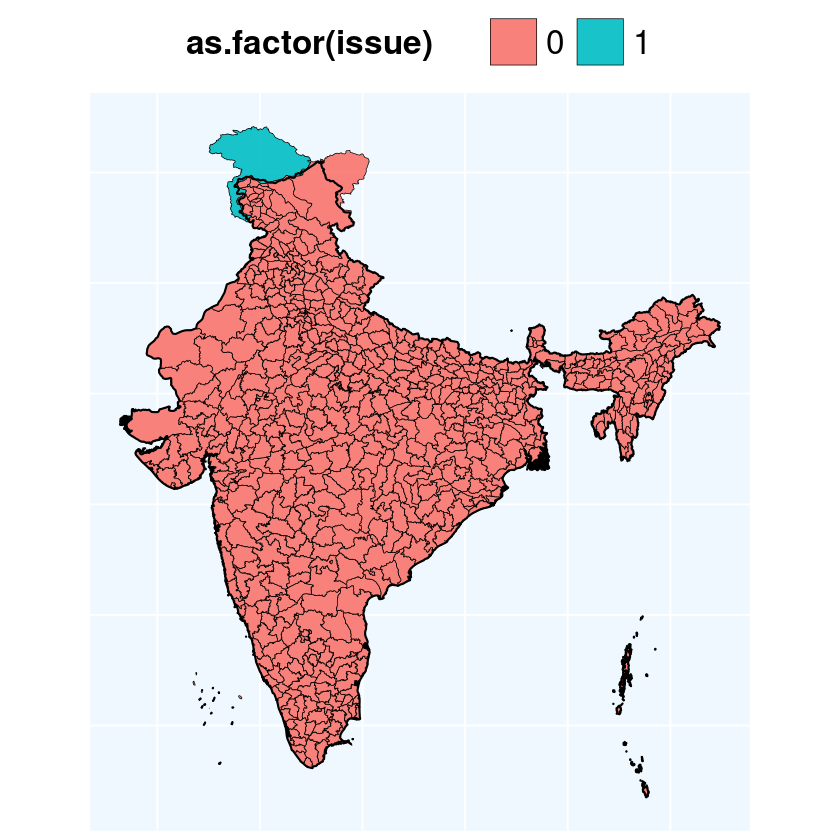

In [10]:
map <- ggplot()+
               geom_sf(data = districts%>%mutate(issue=ifelse(toupper(DISTRICT)=="DATA NOT AVAILABLE",1,0)), 
                                                 aes(fill=as.factor(issue)), color="black", lwd=0.2, alpha=0.9)+
               geom_sf(data = india, fill=NA, color="black", lwd=0.6, alpha=0.9)+
               theme_map()+
               theme(plot.title = element_text(size = 40,face ="bold"),
                     legend.position="top",
                     legend.title = element_text(size = 20,face ="bold"),
                     legend.text = element_text(size = 20),
                     axis.title.x = element_blank(),
                     axis.title.y = element_blank())
map

## Transform to dataframe

In [11]:
df_districts <- districts%>% st_drop_geometry()
sprintf("%i x %i dataframe", nrow(df_districts), ncol(df_districts))
head(df_districts)

[1] "641 x 5 dataframe"

,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode
,<chr>,<chr>,<int>,<int>,<dbl>
1,Adilabad,Andhra Pradesh,28,1,532
2,Agra,Uttar Pradesh,9,15,146
3,Ahmadabad,Gujarat,24,7,474
4,Ahmadnagar,Maharashtra,27,26,522
5,Aizawl,Mizoram,15,3,283
6,Ajmer,Rajasthan,8,21,119


In [12]:
df_districts_m <- df_districts %>%
                        filter(DISTRICT != "Data Not Available")%>%
                        select(ST_NM,DISTRICT)%>%
                        mutate(State_shp=toupper(ST_NM),
                               District_shp=toupper(DISTRICT))
sprintf("%i x %i dataframe", nrow(df_districts_m), ncol(df_districts_m))
head(df_districts_m)

[1] "640 x 4 dataframe"

,ST_NM,DISTRICT,State_shp,District_shp
,<chr>,<chr>,<chr>,<chr>
1,Andhra Pradesh,Adilabad,ANDHRA PRADESH,ADILABAD
2,Uttar Pradesh,Agra,UTTAR PRADESH,AGRA
3,Gujarat,Ahmadabad,GUJARAT,AHMADABAD
4,Maharashtra,Ahmadnagar,MAHARASHTRA,AHMADNAGAR
5,Mizoram,Aizawl,MIZORAM,AIZAWL
6,Rajasthan,Ajmer,RAJASTHAN,AJMER


# Match 2015 DHS cluster

In [13]:
df_DHS_15 <- sf_DHS_15 %>%
                    st_drop_geometry()%>%
                    distinct(ADM1NAME,DHSREGNA)%>%
                    mutate(State_DHS=toupper(ADM1NAME),
                           District_DHS=toupper(DHSREGNA))
sprintf("%i x %i dataframe", nrow(df_DHS_15), ncol(df_DHS_15))
head(df_DHS_15)

[1] "640 x 4 dataframe"

,ADM1NAME,DHSREGNA,State_DHS,District_DHS
,<chr>,<chr>,<chr>,<chr>
1,Tamil Nadu,Thiruvallur,TAMIL NADU,THIRUVALLUR
2,Tamil Nadu,Chennai,TAMIL NADU,CHENNAI
3,Tamil Nadu,Kancheepuram,TAMIL NADU,KANCHEEPURAM
4,Tamil Nadu,Vellore,TAMIL NADU,VELLORE
5,Tamil Nadu,Tiruvannamalai,TAMIL NADU,TIRUVANNAMALAI
6,Tamil Nadu,Viluppuram,TAMIL NADU,VILUPPURAM


In [14]:
shp_not_in_DHS <- setdiff(df_districts_m %>% select(State=State_shp,District=District_shp), 
                          df_DHS_15 %>% select(State=State_DHS,District=District_DHS))%>%
                    arrange(State,District)
write_csv(shp_not_in_DHS,"./interm/shp_districts_not_DHS.csv")

In [15]:
DHS_not_in_shp <- setdiff(df_DHS_15 %>% select(State=State_DHS,District=District_DHS),
                          df_districts_m %>% select(State=State_shp,District=District_shp))%>%
                    arrange(State,District)
write_csv(DHS_not_in_shp,"./interm/DHS_districts_not_shp.csv")

In [16]:
manual_matching <- read_csv("./interm/DHS_shp_districts_manual.csv")
sprintf("%i x %i dataframe", nrow(manual_matching), ncol(manual_matching))
head(manual_matching,2)

Rows: 61 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): State_DHS, District_DHS, State_shp, District_shp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "61 x 4 dataframe"

State_DHS,District_DHS,State_shp,District_shp
<chr>,<chr>,<chr>,<chr>
ANDAMAN & NICOBAR ISLANDS,NICOBARS,ANDAMAN & NICOBAR ISLAND,NICOBAR
ANDAMAN & NICOBAR ISLANDS,NORTH & MIDDLE ANDAMAN,ANDAMAN & NICOBAR ISLAND,NORTH & MIDDLE ANDAMAN


In [17]:
df_districts_matching <- df_districts_m %>%
                                left_join(manual_matching,by=c("State_shp","District_shp"))%>%
                                mutate(State_DHS=ifelse(is.na(State_DHS),State_shp,State_DHS),
                                       District_DHS=ifelse(is.na(District_DHS),District_shp,District_DHS))
sprintf("%i x %i dataframe", nrow(df_districts_matching), ncol(df_districts_matching))
head(df_districts_matching,2)

[1] "640 x 6 dataframe"

,ST_NM,DISTRICT,State_shp,District_shp,State_DHS,District_DHS
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Andhra Pradesh,Adilabad,ANDHRA PRADESH,ADILABAD,TELANGANA,ADILABAD
2,Uttar Pradesh,Agra,UTTAR PRADESH,AGRA,UTTAR PRADESH,AGRA


In [18]:
df_DHS_clusters15 <- sf_DHS_15%>%
                            st_drop_geometry()%>%
                            select(DHSCLUST,ADM1NAME,DHSREGNA)%>%
                            left_join(df_DHS_15,by=c("ADM1NAME","DHSREGNA"))%>%
                            left_join(df_districts_matching,by=c("State_DHS","District_DHS"))%>%
                            #Add Telangana to 2011 states
                            mutate(ST_NM=ifelse(State_DHS=="TELANGANA","Telangana",ST_NM))%>%
                            select(DHSCLUST,State_2011=ST_NM,District_2011=DISTRICT)
sprintf("%i x %i dataframe", nrow(df_DHS_clusters15), ncol(df_DHS_clusters15))
head(df_DHS_clusters15)

[1] "28526 x 3 dataframe"

,DHSCLUST,State_2011,District_2011
,<dbl>,<chr>,<chr>
1,310502,Tamil Nadu,Thiruvallur
2,310190,Tamil Nadu,Thiruvallur
3,310070,Tamil Nadu,Thiruvallur
4,310716,Tamil Nadu,Thiruvallur
5,310592,Tamil Nadu,Thiruvallur
6,310068,Tamil Nadu,Thiruvallur


In [19]:
write_csv(df_DHS_clusters15,"./interm/Matching_DHSclusters_2015_census_2011.csv")

# Match 2019 DHS cluster

In [20]:
shp_districts_matching <- districts%>%
                                st_make_valid()%>%
                                filter(DISTRICT!="Data Not Available")%>%
                                left_join(df_districts_matching,by=c("ST_NM","DISTRICT"))%>%
                                #Add Telangana to 2011 states
                                mutate(ST_NM=ifelse(State_DHS=="TELANGANA","Telangana",ST_NM))

In [21]:
sf_DHS_clusters19 <- st_join(sf_DHS_19,
                             shp_districts_matching, 
                             join= st_within, left = FALSE) 

In [22]:
sprintf("%i x %i dataframe", nrow(sf_DHS_clusters19), ncol(sf_DHS_clusters19))
head(sf_DHS_clusters19,2)

[1] "30037 x 30 dataframe"

,DHSID,DHSCC,DHSYEAR,DHSCLUST,CCFIPS,ADM1FIPS,ADM1FIPSNA,ADM1SALBNA,ADM1SALBCO,ADM1DHS,ADM1NAME,DHSREGCO,DHSREGNA,SOURCE,URBAN_RURA,LATNUM,LONGNUM,ALT_GPS,ALT_DEM,DATUM,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,State_shp,District_shp,State_DHS,District_DHS,geometry
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<POINT [°]>
2,IA202000000102,IA,2020,102,IN,NULL,NULL,NULL,NULL,1,JAMMU & KASHMIR,1,Kupwara,GPS,R,34.40418,74.29431,1621,1621,WGS84,Kupwara,Jammu & Kashmir,1,1,1,JAMMU & KASHMIR,KUPWARA,JAMMU & KASHMIR,KUPWARA,POINT (74.29431 34.40418)
3,IA202000000103,IA,2020,103,IN,NULL,NULL,NULL,NULL,1,JAMMU & KASHMIR,1,Kupwara,GPS,R,34.45516,74.36459,1745,1760,WGS84,Kupwara,Jammu & Kashmir,1,1,1,JAMMU & KASHMIR,KUPWARA,JAMMU & KASHMIR,KUPWARA,POINT (74.36459 34.45516)


In [23]:
df_DHS_clusters19 <- sf_DHS_clusters19%>%
                            st_drop_geometry()%>%
                            select(DHSCLUST,State_2011=ST_NM,District_2011=DISTRICT)
sprintf("%i x %i dataframe", nrow(df_DHS_clusters19), ncol(df_DHS_clusters19))
head(df_DHS_clusters19)

[1] "30037 x 3 dataframe"

,DHSCLUST,State_2011,District_2011
,<dbl>,<chr>,<chr>
2,102,Jammu & Kashmir,Kupwara
3,103,Jammu & Kashmir,Kupwara
4,104,Jammu & Kashmir,Kupwara
5,105,Jammu & Kashmir,Kupwara
6,106,Jammu & Kashmir,Kupwara
7,107,Jammu & Kashmir,Kupwara


In [24]:
write_csv(df_DHS_clusters19,"./interm/Matching_DHSclusters_2019_census_2011.csv")